In [49]:
# Import relevant tools, library and load the dataset

import pandas as pd
import sklearn
import matplotlib.pyplot as plt

# Load the Wine dataset
from sklearn.datasets import load_wine
data_wine = load_wine()
X = data_wine.data
Y = data_wine.target

from collections import Counter, defaultdict
import math

print(data_wine.DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

    :Number of Instances: 178
    :Number of Attributes: 13 numeric, predictive attributes and the class
    :Attribute Information:
 		- Alcohol
 		- Malic acid
 		- Ash
		- Alcalinity of ash  
 		- Magnesium
		- Total phenols
 		- Flavanoids
 		- Nonflavanoid phenols
 		- Proanthocyanins
		- Color intensity
 		- Hue
 		- OD280/OD315 of diluted wines
 		- Proline

    - class:
            - class_0
            - class_1
            - class_2
		
    :Summary Statistics:
    
    ============================= ==== ===== ======= =====
                                   Min   Max   Mean     SD
    ============================= ==== ===== ======= =====
    Alcohol:                      11.0  14.8    13.0   0.8
    Malic Acid:                   0.74  5.80    2.34  1.12
    Ash:                          1.36  3.23    2.36  0.27
    Alcalinity of Ash:            10.6  30.0    19.5   3.3
    Ma

In [50]:
# Convert to DataFrame for better visualization
df = pd.DataFrame(data=data_wine.data,  
                  columns=data_wine.feature_names) 
df['target'] = data_wine.target
print (df.head())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  target  
0          

In [45]:
# Split the data into training and testing sets with 70% training and 30% testing
# random_state=42 because the same train and test sets across different executions
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

print(training_set)

     alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0      14.23        1.71  2.43               15.6      127.0           2.80   
1      13.20        1.78  2.14               11.2      100.0           2.65   
2      13.16        2.36  2.67               18.6      101.0           2.80   
3      14.37        1.95  2.50               16.8      113.0           3.85   
4      13.24        2.59  2.87               21.0      118.0           2.80   
..       ...         ...   ...                ...        ...            ...   
119    12.00        3.43  2.00               19.0       87.0           2.00   
120    11.45        2.40  2.42               20.0       96.0           2.90   
121    11.56        2.05  3.23               28.5      119.0           3.18   
122    12.42        4.43  2.73               26.5      102.0           2.20   
123    13.05        5.80  2.13               21.5       86.0           2.62   

     flavanoids  nonflavanoid_phenols  proanthocyan

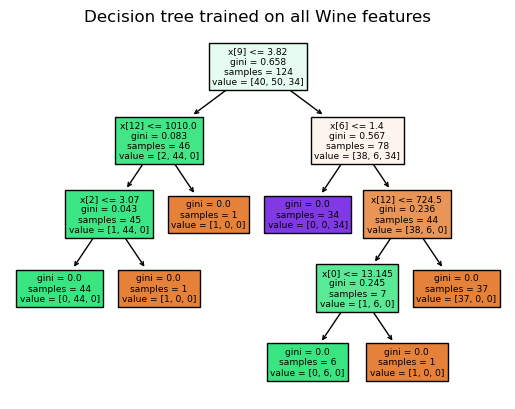

In [46]:
from sklearn import tree

# Create and train the DecisionTreeClassifier
clf = tree.DecisionTreeClassifier(random_state=42)
clf = clf.fit(X_train, Y_train)

# Create a graph visualisation
from sklearn.tree import plot_tree
plt.figure()
plot_tree(clf, filled=True)
plt.title("Decision tree trained on all Wine features")
plt.show()

In [51]:
#Export graph

import graphviz 
dot_data = tree.export_graphviz(clf, out_file=None,
                                feature_names=data_wine.feature_names,
                                class_names=data_wine.target_names,
                                filled=True, rounded=True,
                                special_characters=True)
graph = graphviz.Source(dot_data) 
graph.render("output_graph", format='pdf')


'output_graph.pdf'

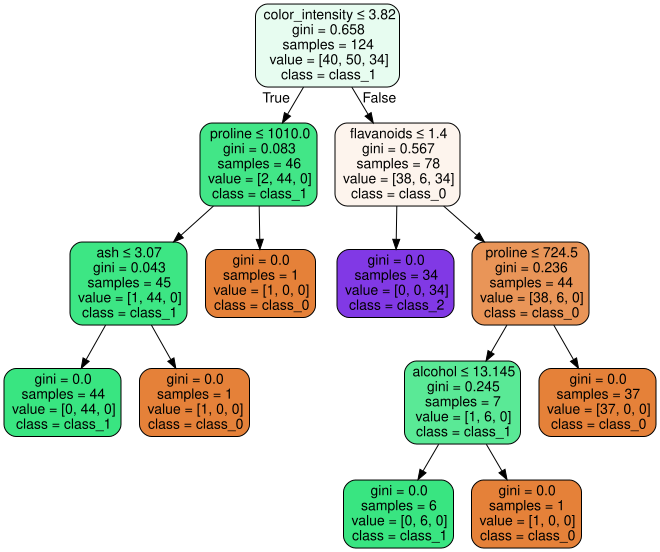

In [52]:
graph 

In [48]:
from sklearn.metrics import accuracy_score, classification_report

# Pass the test set into trained decision tree classifier
predictions = clf.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(Y_test, predictions)
report = classification_report(Y_test, predictions, target_names=data_wine.target_names)

# Print results
print(f"Accuracy: {accuracy}")
print("Classification Report:")
print(report)

Accuracy: 0.9629629629629629
Classification Report:
              precision    recall  f1-score   support

     class_0       0.95      0.95      0.95        19
     class_1       0.95      1.00      0.98        21
     class_2       1.00      0.93      0.96        14

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.96        54
weighted avg       0.96      0.96      0.96        54

